In [48]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

CONFIG = {
    "csv_path": "2026-rev-08-MD.csv",
    "p": 6,
    "split": (0.60, 0.20, 0.20),
    "n_hidden": 16,
    "lr": 0.01,
    "batch_size": 16,
    "max_epochs": 500,
    "patience": 30,
    "seed": 0,
}

torch.manual_seed(CONFIG["seed"])

In [38]:
def fix_fred_century(dates):
    return np.array([
        d.replace(year=d.year - 100) if d.year >= 2059 else d
        for d in pd.to_datetime(dates)
    ])


def load_fred_multiseries(path):
    header = pd.read_csv(path, nrows=0).columns.tolist()
    transform_row = pd.read_csv(path, skiprows=1, nrows=1, header=None).iloc[0]
    df = pd.read_csv(path, skiprows=2, names=header)
    date_col = header[0]
    df[date_col] = pd.to_datetime(df[date_col], format="%m/%d/%y")
    df[date_col] = fix_fred_century(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    series_cols = header[1:]
    transform_codes = {col: int(transform_row[i + 1]) for i, col in enumerate(series_cols)}
    for col in series_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df, date_col, series_cols, transform_codes


def apply_fred_transform(series, code):
    """Apply FRED transformation code. Returns (transformed_series, date_offset)."""
    x = np.asarray(series, dtype=np.float64)
    if code == 2:
        return np.diff(x).astype(np.float32), 1
    if code == 5:
        out = (x[12:] / x[:-12] - 1) * 100
        return out.astype(np.float32), 12
    if code == 6:
        out = ((x[1:] / x[:-1]) ** 12 - 1) * 100
        return out.astype(np.float32), 1
    raise ValueError(f"Unsupported FRED transform code: {code}")


def create_windows(series, p):
    X, y = [], []
    for t in range(p, len(series)):
        X.append(series[t - p:t])
        y.append(series[t])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def chronological_split(X, y, ratios=(0.60, 0.20, 0.20)):
    n = len(X)
    train_end = int(n * ratios[0])
    val_end = int(n * (ratios[0] + ratios[1]))
    return (
        X[:train_end], y[:train_end],
        X[train_end:val_end], y[train_end:val_end],
        X[val_end:], y[val_end:],
    )


def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    return X_t, y_t


def evaluate_mse(model, X_t, y_t, loss_fn):
    model.eval()
    with torch.no_grad():
        return loss_fn(model(X_t), y_t).item()


def compute_baseline_mse(X_train, y_train, X_split, y_split):
    zero_mse = float(np.mean(y_split ** 2))
    persist_mse = float(np.mean((y_split - X_split[:, -1]) ** 2))
    train_mean = float(np.mean(y_train))
    mean_mse = float(np.mean((y_split - train_mean) ** 2))
    return zero_mse, persist_mse, mean_mse

In [39]:
class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(num_features))
        self.affine_bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode):
        if mode == "norm":
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.std = x.std(dim=1, keepdim=True, unbiased=False).detach() + self.eps
            x = (x - self.mean) / self.std
            x = x * self.affine_weight + self.affine_bias
            return x
        elif mode == "denorm":
            x = (x - self.affine_bias) / self.affine_weight
            x = x * self.std + self.mean
            return x
        raise ValueError("mode must be 'norm' or 'denorm'")

In [40]:
class FullyConnectedNN(nn.Module):
    def __init__(self, p, n_hidden=16):
        super().__init__()
        self.revin = RevIN(num_features=1)
        self.hidden = nn.Linear(p, n_hidden)
        self.act = nn.ReLU()
        self.output = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x_norm = self.revin(x, mode="norm")
        x_flat = x_norm.squeeze(-1)
        h = self.act(self.hidden(x_flat))
        pred_norm = self.output(h).unsqueeze(1)
        pred = self.revin(pred_norm, mode="denorm")
        return pred.squeeze(1)

In [41]:
def train_model(X_train_t, y_train_t, X_val_t, y_val_t, config):
    model = FullyConnectedNN(p=config["p"], n_hidden=config["n_hidden"])
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=config["batch_size"],
        shuffle=True,
    )

    best_val = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(config["max_epochs"]):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_mse = evaluate_mse(model, X_val_t, y_val_t, loss_fn)
        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config["patience"]:
                break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val

In [49]:
def run_series_pipeline(series_name, raw_values, dates, transform_code, config):
    raw = np.asarray(pd.to_numeric(raw_values, errors="coerce"), dtype=np.float64)
    dates = np.asarray(dates)
    valid = ~np.isnan(raw)
    raw = raw[valid]
    dates = dates[valid]

    transformed, date_offset = apply_fred_transform(raw, transform_code)
    dates = dates[date_offset:]
    valid = ~np.isnan(transformed) & ~np.isinf(transformed)
    series = transformed[valid]
    dates = dates[valid]

    p = config["p"]
    X, y = create_windows(series, p)
    X_train, y_train, X_val, y_val, X_test, y_test = chronological_split(X, y, config["split"])

    X_train_t, y_train_t = to_tensor(X_train, y_train)
    X_val_t, y_val_t = to_tensor(X_val, y_val)
    X_test_t, y_test_t = to_tensor(X_test, y_test)

    torch.manual_seed(config["seed"])
    model, best_epoch, val_mse = train_model(X_train_t, y_train_t, X_val_t, y_val_t, config)
    loss_fn = nn.MSELoss()
    train_mse = evaluate_mse(model, X_train_t, y_train_t, loss_fn)
    test_mse = evaluate_mse(model, X_test_t, y_test_t, loss_fn)

    zero_mse, persist_mse, mean_mse = compute_baseline_mse(X_train, y_train, X_test, y_test)

    return {
        "series": series_name,
        "transform": transform_code,
        "best_epoch": best_epoch,
        "n_train": len(y_train),
        "n_val": len(y_val),
        "n_test": len(y_test),
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_mse": test_mse,
        "zero_mse": zero_mse,
        "persist_mse": persist_mse,
        "mean_mse": mean_mse,
        "beats_persist": test_mse < persist_mse,
        "model": model,
        "y_test": y_test,
        "X_test": X_test,
        "dates": dates,
        "p": p,
        "val_end_idx": len(y_train) + len(y_val),
    }

In [50]:
df, date_col, series_cols, transform_codes = load_fred_multiseries(CONFIG["csv_path"])
print("Transform codes:", transform_codes)
print(df[[date_col] + series_cols].head())

results = []
for col in series_cols:
    print(f"\nTraining {col} (FRED code {transform_codes[col]})...")
    result = run_series_pipeline(
        col,
        df[col].values,
        df[date_col].values,
        transform_codes[col],
        CONFIG,
    )
    results.append(result)
    print(
        f"  best_epoch={result['best_epoch']}, val_mse={result['val_mse']:.4f}, "
        f"test_mse={result['test_mse']:.4f}, persist_mse={result['persist_mse']:.4f}"
    )

Transform codes: {'RPI': 5, 'UNRATE': 2, 'DPCERA3M086SBEA': 5, 'GS5': 2, 'CPIAUCSL': 6}
     sasdate       RPI  UNRATE  DPCERA3M086SBEA   GS5  CPIAUCSL
0 1959-01-01  2583.560     6.0           15.188  4.01     29.01
1 1959-02-01  2593.596     5.9           15.346  3.96     29.00
2 1959-03-01  2610.396     5.6           15.491  3.99     28.97
3 1959-04-01  2627.446     5.2           15.435  4.12     28.98
4 1959-05-01  2642.720     5.1           15.622  4.35     29.04

Training RPI (FRED code 5)...
  best_epoch=17, val_mse=0.9352, test_mse=14.1454, persist_mse=15.3146

Training UNRATE (FRED code 2)...
  best_epoch=0, val_mse=0.0220, test_mse=0.9296, persist_mse=1.5347

Training DPCERA3M086SBEA (FRED code 5)...
  best_epoch=8, val_mse=0.3065, test_mse=5.2847, persist_mse=4.7355

Training GS5 (FRED code 2)...
  best_epoch=0, val_mse=0.0716, test_mse=0.0380, persist_mse=0.0521

Training CPIAUCSL (FRED code 6)...
  best_epoch=0, val_mse=16.4502, test_mse=9.4638, persist_mse=11.1044


In [51]:
summary = pd.DataFrame([
    {
        "series": r["series"],
        "transform": r["transform"],
        "n_train": r["n_train"],
        "n_val": r["n_val"],
        "n_test": r["n_test"],
        "best_epoch": r["best_epoch"],
        "train_mse": r["train_mse"],
        "val_mse": r["val_mse"],
        "test_mse": r["test_mse"],
        "zero_mse": r["zero_mse"],
        "persist_mse": r["persist_mse"],
        "mean_mse": r["mean_mse"],
        "beats_persist": r["beats_persist"],
    }
    for r in results
])
summary

,series,transform,n_train,n_val,n_test,best_epoch,train_mse,val_mse,test_mse,zero_mse,persist_mse,mean_mse,beats_persist
0,RPI,5,475,159,159,17,0.358094,0.935205,14.145400,19.390888,15.314644,13.633367,True
1,UNRATE,2,481,161,161,0,0.033301,0.022045,0.929558,0.775217,1.534658,0.775130,True
2,DPCERA3M086SBEA,5,475,159,159,8,0.640010,0.306540,5.284728,18.082848,4.735528,11.353699,False
3,GS5,2,482,161,161,0,0.127207,0.071564,0.038030,0.038612,0.052149,0.038509,True
4,CPIAUCSL,6,481,161,161,0,6.984228,16.450190,9.463832,19.588673,11.104382,14.775997,True


In [52]:
run_summary = summary.copy()
for key, val in CONFIG.items():
    if isinstance(val, (tuple, list)):
        run_summary[key] = str(val)  # e.g. "(0.6, 0.2, 0.2)"
    else:
        run_summary[key] = val

run_summary["run_id"] = "baseline_p6_lr0.01"

log_path = "experiment_log.csv"
if os.path.exists(log_path):
    old = pd.read_csv(log_path)
    combined = pd.concat([old, run_summary], ignore_index=True)
else:
    combined = run_summary

combined.to_csv(log_path, index=False)
print(f"Saved to {log_path} ({len(combined)} total rows)")
combined.tail(10)

Saved to experiment_log.csv (10 total rows)


,series,transform,n_train,n_val,n_test,best_epoch,train_mse,val_mse,test_mse,zero_mse,...,csv_path,p,split,n_hidden,lr,batch_size,max_epochs,patience,seed,run_id
0,RPI,5,475,159,159,11,0.349453,0.950490,14.431060,19.390888,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,42,baseline_p6_lr0.01
1,UNRATE,2,481,161,161,5,0.032178,0.022836,1.040795,0.775217,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,42,baseline_p6_lr0.01
2,DPCERA3M086SBEA,5,475,159,159,11,0.633799,0.306275,5.290092,18.082848,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,42,baseline_p6_lr0.01
3,GS5,2,482,161,161,0,0.129347,0.072380,0.038038,0.038612,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,42,baseline_p6_lr0.01
4,CPIAUCSL,6,481,161,161,2,6.811029,16.168497,9.700260,19.588673,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,42,baseline_p6_lr0.01
5,RPI,5,475,159,159,17,0.358094,0.935205,14.145400,19.390888,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,0,baseline_p6_lr0.01
6,UNRATE,2,481,161,161,0,0.033301,0.022045,0.929558,0.775217,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,0,baseline_p6_lr0.01
7,DPCERA3M086SBEA,5,475,159,159,8,0.640010,0.306540,5.284728,18.082848,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,0,baseline_p6_lr0.01
8,GS5,2,482,161,161,0,0.127207,0.071564,0.038030,0.038612,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,0,baseline_p6_lr0.01
9,CPIAUCSL,6,481,161,161,0,6.984228,16.450190,9.463832,19.588673,...,2026-rev-08-MD.csv,6,"(0.6, 0.2, 0.2)",16,0.01,16,500,30,0,baseline_p6_lr0.01


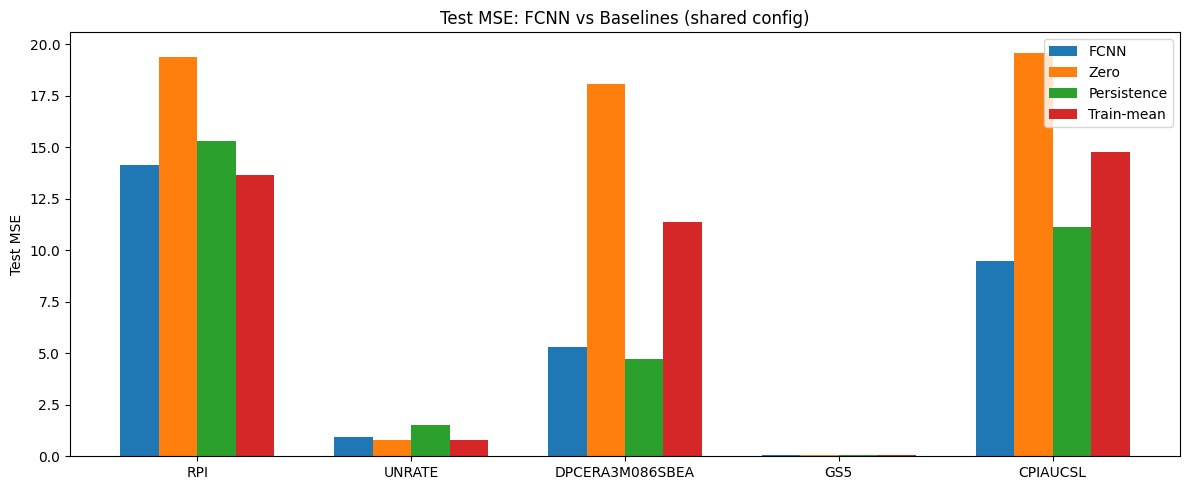

In [53]:
methods = ["FCNN", "Zero", "Persistence", "Train-mean"]
x = np.arange(len(results))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
for i, method in enumerate(methods):
    if method == "FCNN":
        vals = [r["test_mse"] for r in results]
    elif method == "Zero":
        vals = [r["zero_mse"] for r in results]
    elif method == "Persistence":
        vals = [r["persist_mse"] for r in results]
    else:
        vals = [r["mean_mse"] for r in results]
    ax.bar(x + (i - 1.5) * width, vals, width, label=method)

ax.set_xticks(x)
ax.set_xticklabels([r["series"] for r in results])
ax.set_ylabel("Test MSE")
ax.set_title("Test MSE: FCNN vs Baselines (shared config)")
ax.legend()
plt.tight_layout()
plt.show()

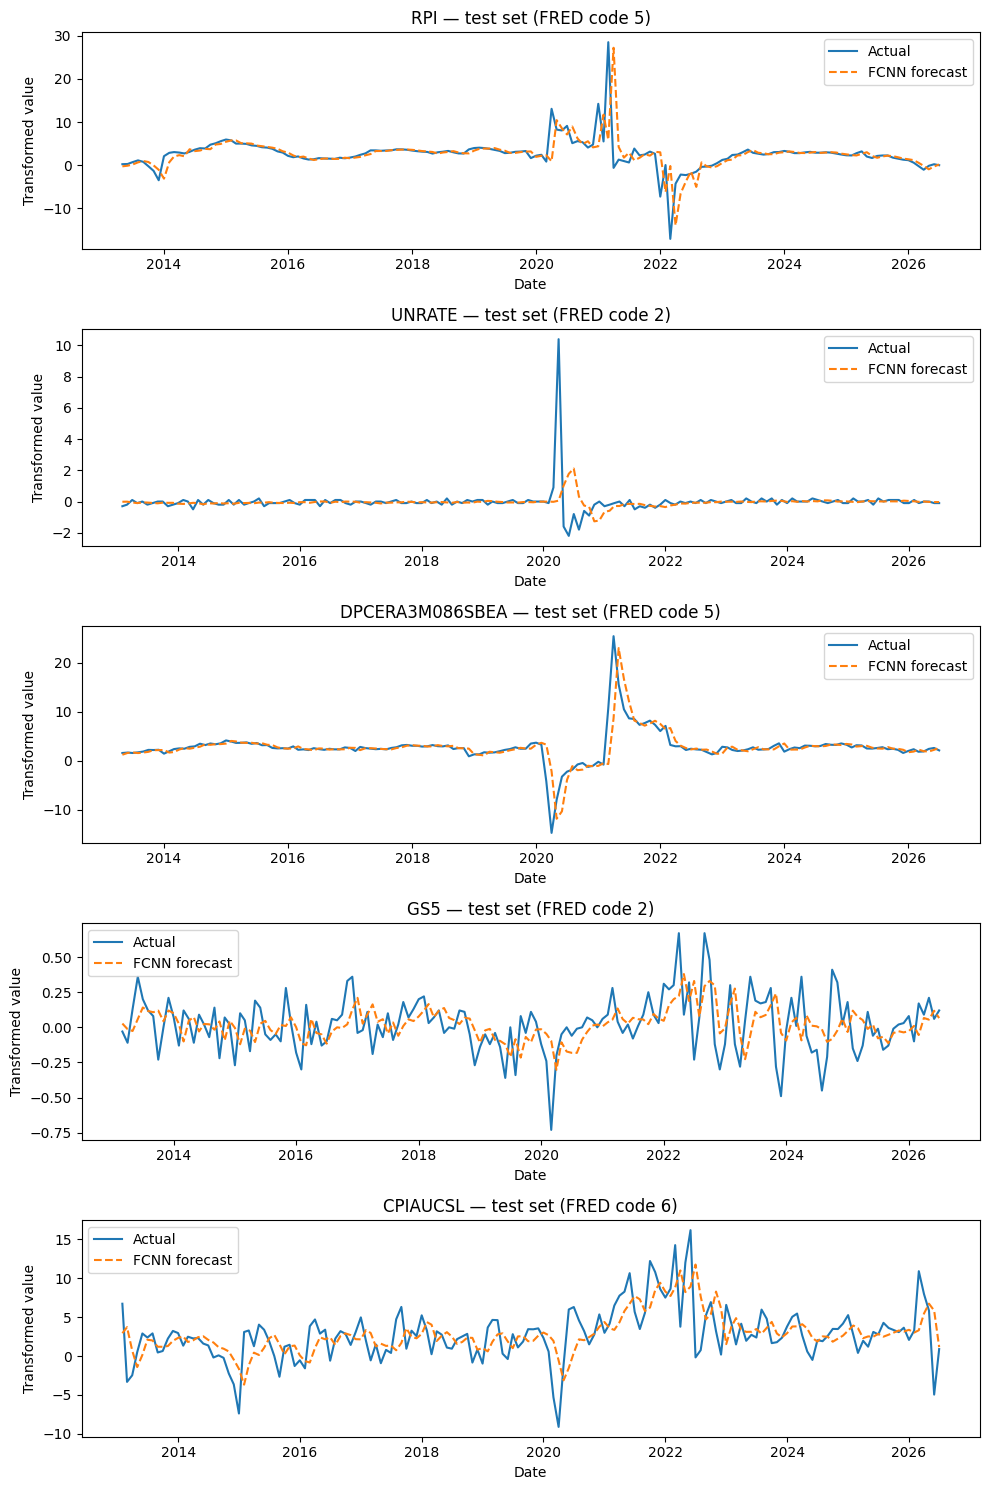

In [54]:
fig, axes = plt.subplots(len(results), 1, figsize=(10, 3 * len(results)), sharex=False)
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    model = r["model"]
    X_test_t, _ = to_tensor(r["X_test"], r["y_test"])
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t).squeeze(-1).numpy()

    test_dates = r["dates"][r["p"] + r["val_end_idx"]:]
    ax.plot(test_dates, r["y_test"], label="Actual")
    ax.plot(test_dates, test_pred, label="FCNN forecast", linestyle="--")
    ax.set_title(f"{r['series']} — test set (FRED code {r['transform']})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Transformed value")
    ax.legend()

plt.tight_layout()
plt.show()